# Part 3: Multi-Agent Supervisor

> Objective: This part evaluates the ability to design and implement a multi-agent system  using a supervisor pattern. Using the same data source, you will orchestrate a team of specialised agents to answer a complex query. 


In [5]:
from ai_engineering_assignment.part3.graph import build_graph
from ai_engineering_assignment.part3.state import ReportState
from ai_engineering_assignment.part3.formatting import format_stream_update
from ai_engineering_assignment.part3.widget import show_widget

from IPython.display import Image, display

We will use the subagent multi-agent pattern, where we will send instructions to the two agents in parallel, then at the end combine the results

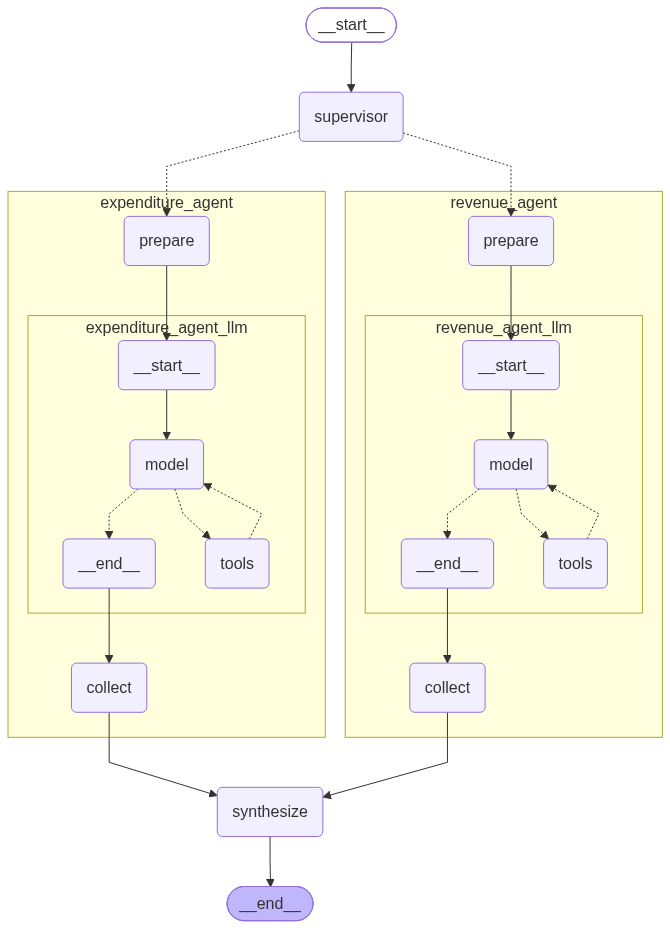

In [4]:
graph = await build_graph()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [5]:
def initial_state(query: str, doc_json_path: str) -> ReportState:
    return {
        "query": query,
        "doc_json_path": doc_json_path,
        "agent_image_paths": {},
        "agent_self_ref_image_paths": {},
        "plan": [],
        "agent_findings": {},
        "final_report": "",
    }

In [6]:
def compact_result(state: ReportState) -> dict:
    # To get the full image_paths across the two agents, we can merge the individual results
    final_self_ref_image_paths = {
        ref: image_path
        for agent_mappings in state["agent_self_ref_image_paths"].values()
        for ref, image_path in agent_mappings.items()
    }

    return {
        "agent_findings": state["agent_findings"],
        "agent_image_paths": state["agent_image_paths"],
        "agent_self_ref_image_paths": state["agent_self_ref_image_paths"],
        "final_self_ref_image_paths": final_self_ref_image_paths,
        "final_report": state["final_report"],
    }

In [5]:
async def stream_report(query: str, doc_json_path: str) -> dict:
    latest_parent_state = None

    async for namespace, stream_mode, chunk in graph.astream(
        initial_state(query=query, doc_json_path=doc_json_path),
        stream_mode=["updates", "values"],
        subgraphs=True,
    ):
        if stream_mode == "updates":
            format_stream_update(namespace, chunk)
        elif stream_mode == "values" and not namespace:
            latest_parent_state = chunk

    if latest_parent_state is None:
        raise RuntimeError(
            "Graph stream completed without returning a final parent state."
        )

    return compact_result(latest_parent_state)

### Query 1: What are the key government revenue streams, and how will the Budget for the Future Energy Fund be supported?

In [6]:
result = await stream_report(
    query="What are the key government revenue streams, and how will the Budget for the Future Energy Fund be supported?",
    doc_json_path="/home/joanna/ai-engineering-assignment/data/7612900673194843087.json",
)


[graph]
├── Node: supervisor
│
├── Supervisor Plan
│   • revenue_agent
│     Identify and extract all key government revenue streams from available sources, including taxes, fees, and other income sources. Additionally, identify specific funding mechanisms and revenue sources dedicated to supporting the Budget for the Future Energy Fund. For each revenue stream identified, provide a source reference.
│   • expenditure_agent
│     Analyze how the Budget for the Future Energy Fund will be funded and supported, including any spending plans, budget allocations, and financial mechanisms. Identify the expenditure structure and how resources will be distributed within this fund. For each finding, provide a source reference.

[revenue_agent]
├── Node: prepare
│
├── 💬 HumanMessage
│     Identify and extract all key government revenue streams from available sources, including taxes, fees, and other income sources. Additionally, identify specific funding mechanisms and revenue sources dedicated 

In [7]:
# Full generated report
print(result["final_report"])

# COMPREHENSIVE GOVERNMENT REVENUE AND FUTURE ENERGY FUND REPORT

## I. MAJOR TAX REVENUE SOURCES (comprising 91.2% of Operating Revenue - FY2024)

### A. Direct Income Taxes

**1. Corporate Income Tax**
- FY2024 Estimate: $28.0 billion (25.8% of operating revenue)
- FY2023 Actual: $28.38 billion (27.2% of operating revenue)
- Source Reference: #/texts/52, #/texts/115, #/tables/4, #/tables/1

**2. Personal Income Tax**
- FY2024 Estimate: $18.1 billion (16.6% of operating revenue)
- FY2023 Actual: $17.53 billion (16.8% of operating revenue)
- Source Reference: #/texts/54, #/texts/116, #/tables/4, #/tables/1

**3. Withholding Tax**
- FY2024 Estimate: $2.3 billion (2.1% of operating revenue)
- FY2023 Actual: $2.19 billion (2.1% of operating revenue)
- Source Reference: #/texts/72, #/texts/119, #/tables/4, #/tables/1

### B. Goods and Services Tax (GST)
- FY2024 Estimate: $19.4 billion (17.9% of operating revenue)
- FY2023 Actual: $16.36 billion (15.7% of operating revenue)
- Source Refere

Here is a widget that allows you to toggle between the different agents and view its findings.

In [ ]:
show_widget(result=result)